In [1]:
!pip -q install transformers accelerate scikit-learn iterative-stratification openpyxl gradio

import gc
import os
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
from torch.nn import BCEWithLogitsLoss
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from google.colab import drive

drive.mount("/content/drive")

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_MODEL = "SamLowe/roberta-base-go_emotions"
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/Data Sets"
OUTPUT_DIR = "/content/drive/MyDrive/GoEmotions_imbalance_experiments"

EXPERIMENTS = ["weighted_ce", "focal_loss", "oversampling"]
LABELS = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral",
]
LABEL2ID = {label: idx for idx, label in enumerate(LABELS)}
ID2LABEL = {idx: label for label, idx in LABEL2ID.items()}
FOCUS_LABELS = ["grief", "remorse", "fear", "nervousness"]
FOCUS_IDS = [LABEL2ID[label] for label in FOCUS_LABELS]

MAX_LENGTH = 64
EPOCHS = 1
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
THRESHOLD = 0.35
QUICK_RUN = True
MAX_TRAIN_SAMPLES = 12000

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Base checkpoint: {BASE_MODEL}")
print(f"Drive data folder: {DATA_DIR}")
print(f"Output folder: {OUTPUT_DIR}")
print(f"Quick run enabled: {QUICK_RUN}")

Mounted at /content/drive
Device: cuda
Base checkpoint: SamLowe/roberta-base-go_emotions
Drive data folder: /content/drive/MyDrive/Colab Notebooks/Data Sets
Output folder: /content/drive/MyDrive/GoEmotions_imbalance_experiments
Quick run enabled: True


Raw rows loaded: 211,225
Clean examples after agreement filtering: 54,263
Labels used: 28 (27 emotions + neutral)
Average labels per example: 1.18

Rare focus labels:
grief           96.0
remorse        669.0
fear           764.0
nervousness    208.0


/tmp/ipykernel_539/2826132329.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, palette="mako")


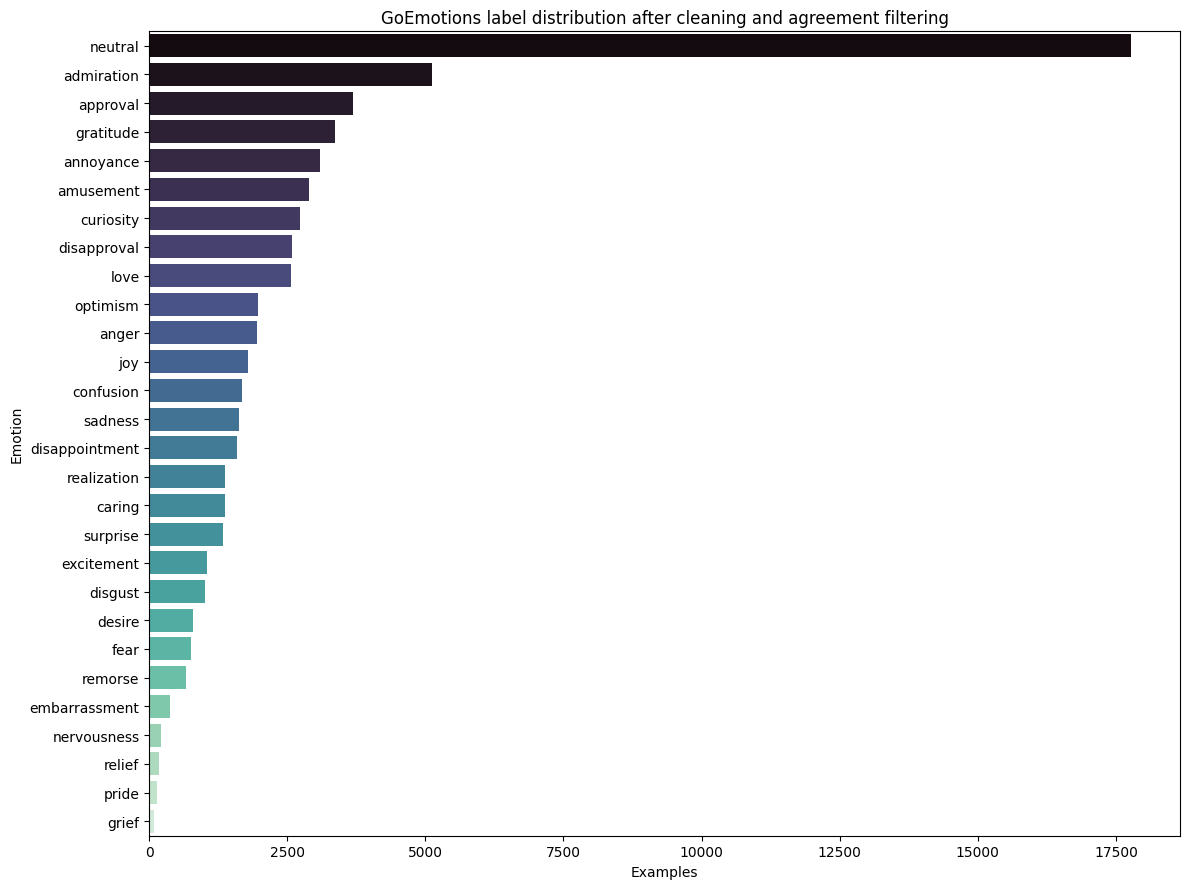

In [2]:
# Load the three Excel shards from Drive and convert them into one cleaned table.

def load_excel_shard(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    frame = pd.read_excel(path, engine="openpyxl")
    frame.columns = [str(column).strip().lower() for column in frame.columns]
    return frame


def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def labels_to_multihot(label_value):
    vector = np.zeros(len(LABELS), dtype=np.float32)
    if isinstance(label_value, (list, tuple, set)):
        items = [str(item).strip().lower() for item in label_value]
    else:
        items = [item.strip().lower() for item in str(label_value).split(",") if item.strip()]

    for item in items:
        if item.isdigit():
            index = int(item)
            if 0 <= index < len(LABELS):
                vector[index] = 1.0
        elif item in LABEL2ID:
            vector[LABEL2ID[item]] = 1.0
    return vector


def build_examples(frame):
    frame = frame.copy()
    frame.columns = [str(column).strip().lower() for column in frame.columns]
    if "text" not in frame.columns:
        raise ValueError("Each file must contain a text column.")

    label_columns = [label for label in LABELS if label in frame.columns]

    # Case 1: raw annotation rows with emotion columns.
    if label_columns:
        if "id" in frame.columns and frame["id"].duplicated().any():
            grouped = frame.groupby("id", as_index=False).agg(
                {"text": "first", **{column: "sum" for column in label_columns}}
            )
            grouped["label_list"] = grouped[label_columns].apply(
                lambda row: [column for column in label_columns if row[column] >= 2], axis=1
            )
            grouped = grouped[grouped["label_list"].map(len) > 0].copy()
            grouped["labels"] = grouped["label_list"].apply(lambda items: ",".join(items))
            grouped["text_clean"] = grouped["text"].apply(clean_text)
            grouped["label_vector"] = grouped["label_list"].apply(labels_to_multihot)
            keep_columns = [column for column in ["id", "text"] if column in grouped.columns]
            keep_columns += ["text_clean", "labels", "label_vector"]
            return grouped[keep_columns]

        binary_emotions = frame[label_columns].fillna(0).astype(int)
        frame["label_list"] = binary_emotions.apply(
            lambda row: [column for column in label_columns if row[column] == 1], axis=1
        )
        frame = frame[frame["label_list"].map(len) > 0].copy()
        frame["labels"] = frame["label_list"].apply(lambda items: ",".join(items))
        frame["text_clean"] = frame["text"].apply(clean_text)
        frame["label_vector"] = frame["label_list"].apply(labels_to_multihot)
        keep_columns = [column for column in ["id", "text"] if column in frame.columns]
        keep_columns += ["text_clean", "labels", "label_vector"]
        return frame[keep_columns]

    # Case 2: already aggregated rows with a labels column.
    if "labels" in frame.columns:
        frame["text_clean"] = frame["text"].apply(clean_text)
        frame["label_vector"] = frame["labels"].apply(labels_to_multihot)
        frame = frame[frame["label_vector"].map(lambda vector: vector.sum() > 0)].copy()
        keep_columns = [column for column in ["id", "text"] if column in frame.columns]
        keep_columns += ["text_clean", "labels", "label_vector"]
        return frame[keep_columns]

    raise ValueError("The files must contain either emotion columns or a labels column.")


goemotions_1_df = load_excel_shard(os.path.join(DATA_DIR, "goemotions_1.xlsx"))
goemotions_2_df = load_excel_shard(os.path.join(DATA_DIR, "goemotions_2.xlsx"))
goemotions_3_df = load_excel_shard(os.path.join(DATA_DIR, "goemotions_3.xlsx"))
raw_df = pd.concat([goemotions_1_df, goemotions_2_df, goemotions_3_df], ignore_index=True)

dataset_df = build_examples(raw_df).reset_index(drop=True)
label_matrix = np.vstack(dataset_df["label_vector"].to_numpy())
label_counts = pd.Series(label_matrix.sum(axis=0), index=LABELS).sort_values(ascending=False)

print(f"Raw rows loaded: {len(raw_df):,}")
print(f"Clean examples after agreement filtering: {len(dataset_df):,}")
print(f"Labels used: {len(LABELS)} (27 emotions + neutral)")
print(f"Average labels per example: {label_matrix.sum(axis=1).mean():.2f}")
print("\nRare focus labels:")
print(label_counts.reindex(FOCUS_LABELS).to_string())

plt.figure(figsize=(12, 9))
sns.barplot(x=label_counts.values, y=label_counts.index, palette="mako")
plt.title("GoEmotions label distribution after cleaning and agreement filtering")
plt.xlabel("Examples")
plt.ylabel("Emotion")
plt.tight_layout()
plt.show()

In [3]:
# Build a multilabel-stratified 80/10/10 split and prepare the shared training objects.

dummy_features = np.zeros((len(dataset_df), 1))
full_labels = np.vstack(dataset_df["label_vector"].to_numpy())

splitter = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
train_idx, temp_idx = next(splitter.split(dummy_features, full_labels))
train_df = dataset_df.iloc[train_idx].reset_index(drop=True)
temp_df = dataset_df.iloc[temp_idx].reset_index(drop=True)

temp_labels = np.vstack(temp_df["label_vector"].to_numpy())
splitter_2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
val_idx, test_idx = next(splitter_2.split(np.zeros((len(temp_df), 1)), temp_labels))
val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

if QUICK_RUN and len(train_df) > MAX_TRAIN_SAMPLES:
    train_df = train_df.sample(n=MAX_TRAIN_SAMPLES, random_state=SEED).reset_index(drop=True)

print(f"Train split: {len(train_df):,}")
print(f"Validation split: {len(val_df):,}")
print(f"Test split: {len(test_df):,}")
print(f"Split type: multilabel-stratified shuffle split (80/10/10)")

# The same tokenizer, maximum length, and padding rules are reused in every experiment.
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


class EmotionDataset(Dataset):
    def __init__(self, frame, tokenizer, max_length=MAX_LENGTH):
        self.labels = np.vstack(frame["label_vector"].to_numpy()).astype(np.float32)
        self.encodings = tokenizer(
            frame["text_clean"].tolist(),
            truncation=True,
            max_length=max_length,
            padding=False,
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        item = {key: torch.tensor(value[index]) for key, value in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[index], dtype=torch.float32)
        return item


train_dataset = EmotionDataset(train_df, tokenizer)
val_dataset = EmotionDataset(val_df, tokenizer)
test_dataset = EmotionDataset(test_df, tokenizer)

# Compute class weights from the training split only so the evaluation data does not leak into the loss.
train_label_matrix = np.vstack(train_df["label_vector"].to_numpy())
label_counts_train = train_label_matrix.sum(axis=0)
label_counts_train = np.maximum(label_counts_train, 1.0)
negative_counts = len(train_df) - label_counts_train
pos_weight_values = np.maximum(negative_counts / label_counts_train, 1.0)
pos_weight_values = np.clip(pos_weight_values, 1.0, 20.0)
pos_weight_tensor = torch.tensor(pos_weight_values, dtype=torch.float32)

# Oversampling uses the inverse class frequency of the active labels in each sample.
inverse_frequency = 1.0 / label_counts_train
sample_weights = []
for row in train_label_matrix:
    active = row > 0
    if active.any():
        sample_weights.append(float(inverse_frequency[active].mean()))
    else:
        sample_weights.append(float(inverse_frequency.mean()))
sample_weights = np.asarray(sample_weights, dtype=np.float64)
sample_weights = sample_weights / sample_weights.mean()
train_sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)


def sigmoid_np(values):
    return 1.0 / (1.0 + np.exp(-values))


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probabilities = sigmoid_np(logits)
    predictions = (probabilities >= THRESHOLD).astype(int)

    micro_precision, micro_recall, _, _ = precision_recall_fscore_support(
        labels, predictions, average="micro", zero_division=0
    )
    macro_precision, macro_recall, _, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0
    )

    metrics = {
        "accuracy": accuracy_score(labels, predictions),
        "micro_precision": micro_precision,
        "micro_recall": micro_recall,
        "micro_f1": f1_score(labels, predictions, average="micro", zero_division=0),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": f1_score(labels, predictions, average="macro", zero_division=0),
        "weighted_f1": f1_score(labels, predictions, average="weighted", zero_division=0),
    }

    focus_scores = []
    for label in FOCUS_LABELS:
        label_index = LABEL2ID[label]
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels[:, label_index],
            predictions[:, label_index],
            average="binary",
            zero_division=0,
        )
        metrics[f"{label}_precision"] = precision
        metrics[f"{label}_recall"] = recall
        metrics[f"{label}_f1"] = f1
        focus_scores.append(f1)

    metrics["focus_f1"] = float(np.mean(focus_scores))
    return metrics


def build_model():
    return AutoModelForSequenceClassification.from_pretrained(
        BASE_MODEL,
        num_labels=len(LABELS),
        problem_type="multi_label_classification",
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )


class EmotionTrainer(Trainer):
    def __init__(self, loss_mode="weighted_ce", pos_weight=None, sampler=None, **kwargs):
        super().__init__(**kwargs)
        self.loss_mode = loss_mode
        self.pos_weight = pos_weight
        self.sampler = sampler

    def get_train_dataloader(self):
        if self.sampler is None:
            return super().get_train_dataloader()
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.train_batch_size,
            sampler=self.sampler,
            collate_fn=self.data_collator,
            num_workers=2,
            pin_memory=torch.cuda.is_available(),
        )

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        del num_items_in_batch
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits

        if self.loss_mode == "weighted_ce":
            if self.pos_weight is None:
                raise ValueError("weighted_ce requires pos_weight")
            loss_fct = BCEWithLogitsLoss(pos_weight=self.pos_weight.to(logits.device))
            loss = loss_fct(logits, labels)
        elif self.loss_mode == "focal_loss":
            probabilities = torch.sigmoid(logits)
            bce = F.binary_cross_entropy_with_logits(logits, labels, reduction="none")
            pt = labels * probabilities + (1 - labels) * (1 - probabilities)
            alpha = 0.25
            gamma = 2.0
            alpha_factor = labels * alpha + (1 - labels) * (1 - alpha)
            loss = (alpha_factor * (1 - pt).pow(gamma) * bce).mean()
        else:
            loss = F.binary_cross_entropy_with_logits(logits, labels)

        return (loss, outputs) if return_outputs else loss

Train split: 12,000
Validation split: 2,721
Test split: 2,729
Split type: multilabel-stratified shuffle split (80/10/10)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [4]:
# Train the weighted CE experiment with the same data, tokenizer, and split.

import inspect
import math

experiment_results = {}


def train_one_experiment(experiment_name):
    model = build_model()
    output_dir = os.path.join(OUTPUT_DIR, experiment_name)

    training_args_kwargs = dict(
        output_dir=output_dir,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        lr_scheduler_type="linear",
        logging_strategy="epoch",
        save_strategy="no",
        report_to="none",
        fp16=torch.cuda.is_available(),
        gradient_accumulation_steps=2,
        remove_unused_columns=False,
        seed=SEED,
        dataloader_num_workers=2,
    )
    total_train_steps = math.ceil(len(train_dataset) / (TRAIN_BATCH_SIZE * 2)) * EPOCHS
    training_args_kwargs["warmup_steps"] = max(1, int(0.05 * total_train_steps))

    training_strategy_param = "evaluation_strategy"
    if training_strategy_param not in inspect.signature(TrainingArguments.__init__).parameters:
        training_strategy_param = "eval_strategy"
    training_args_kwargs[training_strategy_param] = "epoch"
    training_args = TrainingArguments(**training_args_kwargs)

    trainer_kwargs = dict(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer_init_params = inspect.signature(Trainer.__init__).parameters
    if "tokenizer" in trainer_init_params:
        trainer_kwargs["tokenizer"] = tokenizer
    elif "processing_class" in trainer_init_params:
        trainer_kwargs["processing_class"] = tokenizer

    if experiment_name == "weighted_ce":
        trainer = EmotionTrainer(
            loss_mode="weighted_ce",
            pos_weight=pos_weight_tensor,
            sampler=None,
            **trainer_kwargs,
        )
    elif experiment_name == "focal_loss":
        trainer = EmotionTrainer(
            loss_mode="focal_loss",
            pos_weight=pos_weight_tensor,
            sampler=None,
            **trainer_kwargs,
        )
    else:
        trainer = EmotionTrainer(
            loss_mode="standard",
            pos_weight=pos_weight_tensor,
            sampler=train_sampler,
            **trainer_kwargs,
        )

    print(f"\n===== Training {experiment_name} =====")
    trainer.train()
    val_metrics = trainer.evaluate(val_dataset)
    test_metrics = trainer.evaluate(test_dataset)

    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    del trainer
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return val_metrics, test_metrics, output_dir


val_metrics, test_metrics, model_dir = train_one_experiment("weighted_ce")
experiment_results["weighted_ce"] = {
    "val": val_metrics,
    "test": test_metrics,
    "model_dir": model_dir,
}
print(f"Finished weighted_ce | val focus F1: {val_metrics['eval_focus_f1']:.4f} | test focus F1: {test_metrics['eval_focus_f1']:.4f}")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



===== Training weighted_ce =====


Epoch,Training Loss,Validation Loss,Accuracy,Micro Precision,Micro Recall,Micro F1,Macro Precision,Macro Recall,Macro F1,Weighted F1,Grief Precision,Grief Recall,Grief F1,Remorse Precision,Remorse Recall,Remorse F1,Fear Precision,Fear Recall,Fear F1,Nervousness Precision,Nervousness Recall,Nervousness F1,Focus F1
1,0.777152,0.324128,0.112826,0.307365,0.904762,0.458850,0.286474,0.889568,0.415914,0.531342,0.075000,0.600000,0.133333,0.471429,0.970588,0.634615,0.306306,0.894737,0.456376,0.166667,1.000000,0.285714,0.377510


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Finished weighted_ce | val focus F1: 0.3775 | test focus F1: 0.4398


In [5]:
# Train the focal loss experiment with the same data, tokenizer, and split.

val_metrics, test_metrics, model_dir = train_one_experiment("focal_loss")
experiment_results["focal_loss"] = {
    "val": val_metrics,
    "test": test_metrics,
    "model_dir": model_dir,
}
print(f"Finished focal_loss | val focus F1: {val_metrics['eval_focus_f1']:.4f} | test focus F1: {test_metrics['eval_focus_f1']:.4f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



===== Training focal_loss =====


Epoch,Training Loss,Validation Loss,Accuracy,Micro Precision,Micro Recall,Micro F1,Macro Precision,Macro Recall,Macro F1,Weighted F1,Grief Precision,Grief Recall,Grief F1,Remorse Precision,Remorse Recall,Remorse F1,Fear Precision,Fear Recall,Fear F1,Nervousness Precision,Nervousness Recall,Nervousness F1,Focus F1
1,0.017105,0.006980,0.538405,0.689425,0.680138,0.684750,0.608745,0.596897,0.594642,0.673108,0.000000,0.000000,0.000000,0.674419,0.852941,0.753247,0.700000,0.736842,0.717949,0.833333,1.000000,0.909091,0.595072


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Finished focal_loss | val focus F1: 0.5951 | test focus F1: 0.5620


In [6]:
# Train the oversampling experiment with the same data, tokenizer, and split.

val_metrics, test_metrics, model_dir = train_one_experiment("oversampling")
experiment_results["oversampling"] = {
    "val": val_metrics,
    "test": test_metrics,
    "model_dir": model_dir,
}
print(f"Finished oversampling | val focus F1: {val_metrics['eval_focus_f1']:.4f} | test focus F1: {test_metrics['eval_focus_f1']:.4f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



===== Training oversampling =====


Epoch,Training Loss,Validation Loss,Accuracy,Micro Precision,Micro Recall,Micro F1,Macro Precision,Macro Recall,Macro F1,Weighted F1,Grief Precision,Grief Recall,Grief F1,Remorse Precision,Remorse Recall,Remorse F1,Fear Precision,Fear Recall,Fear F1,Nervousness Precision,Nervousness Recall,Nervousness F1,Focus F1
1,0.155799,0.081404,0.446527,0.607702,0.583333,0.595269,0.536701,0.662394,0.575944,0.587729,0.090909,0.200000,0.125000,0.673913,0.911765,0.775000,0.622222,0.736842,0.674699,0.526316,1.000000,0.689655,0.566088


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Finished oversampling | val focus F1: 0.5661 | test focus F1: 0.5842


In [7]:
# Compare the three experiments and select the best checkpoint for inference.

summary_rows = []
for experiment_name, results in experiment_results.items():
    val_metrics = results["val"]
    test_metrics = results["test"]
    summary_rows.append(
        {
            "setup": experiment_name,
            "val_macro_f1": val_metrics["eval_macro_f1"],
            "val_micro_f1": val_metrics["eval_micro_f1"],
            "val_focus_f1": val_metrics["eval_focus_f1"],
            "test_macro_f1": test_metrics["eval_macro_f1"],
            "test_micro_f1": test_metrics["eval_micro_f1"],
            "test_focus_f1": test_metrics["eval_focus_f1"],
            "test_grief_f1": test_metrics["eval_grief_f1"],
            "test_remorse_f1": test_metrics["eval_remorse_f1"],
            "test_fear_f1": test_metrics["eval_fear_f1"],
            "test_nervousness_f1": test_metrics["eval_nervousness_f1"],
        }
    )

results_df = pd.DataFrame(summary_rows).sort_values("val_focus_f1", ascending=False).reset_index(drop=True)
print("\nModel comparison sorted by validation focus F1:")
print(results_df.to_string(index=False))

best_setup = results_df.iloc[0]["setup"]
best_model_dir = experiment_results[best_setup]["model_dir"]
print(f"\nBest setup for the rare-emotion objective: {best_setup}")
print(f"Best model directory: {best_model_dir}")


Model comparison sorted by validation focus F1:
       setup  val_macro_f1  val_micro_f1  val_focus_f1  test_macro_f1  test_micro_f1  test_focus_f1  test_grief_f1  test_remorse_f1  test_fear_f1  test_nervousness_f1
  focal_loss      0.594642      0.684750      0.595072       0.584371       0.685723       0.561992       0.000000         0.784810      0.763158             0.700000
oversampling      0.575944      0.595269      0.566088       0.558694       0.586679       0.584195       0.352941         0.780488      0.657895             0.545455
 weighted_ce      0.415914      0.458850      0.377510       0.408594       0.459257       0.439827       0.190476         0.680412      0.583333             0.305085

Best setup for the rare-emotion objective: focal_loss
Best model directory: /content/drive/MyDrive/GoEmotions_imbalance_experiments/focal_loss


In [8]:
# Build an interactive interface that can switch between the three trained setups.

setup_choice_map = {
    "Weighted CE": "weighted_ce",
    "Focal Loss": "focal_loss",
    "Oversampling": "oversampling",
}
setup_description_map = {
    "Weighted CE": "class-weighted loss for rare labels",
    "Focal Loss": "hard-example-focused loss",
    "Oversampling": "balanced training batches",
}
setup_model_cache = {
    "setup_key": None,
    "tokenizer": None,
    "model": None,
}


def load_setup_assets(setup_label):
    setup_key = setup_choice_map[setup_label]
    if setup_model_cache["setup_key"] != setup_key:
        if setup_model_cache["model"] is not None:
            del setup_model_cache["model"]
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        model_dir = experiment_results[setup_key]["model_dir"]
        tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=True)
        model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE)
        model.eval()
        setup_model_cache["setup_key"] = setup_key
        setup_model_cache["tokenizer"] = tokenizer
        setup_model_cache["model"] = model
    return setup_model_cache["tokenizer"], setup_model_cache["model"]


def predict_emotions(text, setup_label, top_k=5, threshold=THRESHOLD):
    inference_tokenizer, inference_model = load_setup_assets(setup_label)
    cleaned_text = clean_text(text)
    encoded = inference_tokenizer(
        cleaned_text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )
    input_ids = encoded["input_ids"].to(DEVICE)
    attention_mask = encoded["attention_mask"].to(DEVICE)

    with torch.no_grad():
        logits = inference_model(input_ids=input_ids, attention_mask=attention_mask).logits[0]
        probabilities = torch.sigmoid(logits).detach().cpu().numpy()

    ranked_indices = np.argsort(probabilities)[::-1]
    top_rows = []
    for index in ranked_indices[:top_k]:
        top_rows.append(
            {
                "emotion": ID2LABEL[index],
                "probability_%": round(float(probabilities[index] * 100), 2),
            }
        )

    detected = [
        f"{ID2LABEL[index]}: {probabilities[index] * 100:.1f}%"
        for index in ranked_indices
        if probabilities[index] >= threshold
    ]
    if not detected:
        detected = [
            f"{ID2LABEL[ranked_indices[0]]}: {probabilities[ranked_indices[0]] * 100:.1f}%"
        ]

    selected_setup_text = f"Using setup: {setup_label} ({setup_description_map[setup_label]})"
    return cleaned_text, selected_setup_text, pd.DataFrame(top_rows), "\n".join(detected)


example_text = "I feel really anxious about tomorrow."
cleaned_example, example_setup, example_table, example_summary = predict_emotions(
    example_text,
    "Weighted CE",
    top_k=5,
)
print("Example input:", example_text)
print("Cleaned input:", cleaned_example)
print(example_setup)
print("Predicted emotions:")
print(example_summary)
print(example_table.to_string(index=False))


import gradio as gr


def gradio_predict(text, setup_label, top_k):
    cleaned_text, selected_setup_text, table, summary = predict_emotions(
        text,
        setup_label,
        top_k=int(top_k),
    )
    return cleaned_text, selected_setup_text, table, summary


with gr.Blocks() as demo:
    gr.Markdown(
        """
        # GoEmotions Emotion Detector
        Pick one of the three trained setups, then enter text and click Detect emotion.
        """
    )
    with gr.Row():
        setup_box = gr.Radio(
            choices=list(setup_choice_map.keys()),
            value="Weighted CE",
            label="Training setup",
            info="Choose the model variant to use for prediction.",
        )
    with gr.Row():
        input_box = gr.Textbox(
            label="Input text",
            lines=4,
            placeholder="I feel really anxious about tomorrow.",
        )
    with gr.Row():
        top_k_slider = gr.Slider(
            minimum=1,
            maximum=10,
            value=5,
            step=1,
            label="Top-K emotions to display",
        )
    with gr.Row():
        cleaned_box = gr.Textbox(label="Cleaned text")
        setup_info_box = gr.Textbox(label="Selected setup")
    with gr.Row():
        table_box = gr.Dataframe(label="Emotion probabilities", wrap=True)
    with gr.Row():
        summary_box = gr.Textbox(
            label="Detected emotions above threshold",
            lines=4,
        )
    run_button = gr.Button("Detect emotion")
    run_button.click(
        fn=gradio_predict,
        inputs=[input_box, setup_box, top_k_slider],
        outputs=[cleaned_box, setup_info_box, table_box, summary_box],
    )

demo.launch(share=True)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Example input: I feel really anxious about tomorrow.
Cleaned input: i feel really anxious about tomorrow
Using setup: Weighted CE (class-weighted loss for rare labels)
Predicted emotions:
nervousness: 98.0%
fear: 88.9%
sadness: 46.4%
excitement: 44.3%
caring: 37.7%
    emotion  probability_%
nervousness          97.97
       fear          88.86
    sadness          46.38
 excitement          44.27
     caring          37.69
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6811f718b4ab0a8b64.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
